# How to Load Nanodet in PyTorch

This article is an introductory tutorial to infer nanodet with PyTorch.

**Note**, we suppose this notebook is in the root directory of nonadet!

## Install nanodet first

For us to begin with, PyTorch should be installed. TorchVision is also required since we will be using it as our model zoo.

A quick solution is to install via pip

```shell
pip install torch==1.7.1
pip install torchvision==0.8.2
```

or please refer to official site https://pytorch.org/get-started/locally/

PyTorch versions should be backwards compatible but should be used with the proper TorchVision version.

And then don't forget to install other dependencies.

```shell
pip install -r requirements.txt
```

Next enter the key part, let's install `nanodet`!

```shell
python setup.py develop
```

## Set Environmental Parameters

In [17]:
import os
import cv2
import torch

In [ ]:
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"]="0"

device = torch.device('cuda')

In [2]:
torch.backends.cudnn.enabled = True
torch.backends.cudnn.benchmark = True

## Set Model Configuration and Logger

In [38]:
from nanodet.util import cfg, load_config, Logger

In [65]:
config_path = '../config/nanodet-custom_yolo.yml'
model_path = '../workspace/nanodet-custom_yolo/model_last.ckpt'
image_path = '../data/V2.0-BC/TRAIN/IMAGES/raw-250110_dc_s001_b2_3.jpg'

In [66]:
load_config(cfg, config_path)
logger = Logger(-1, use_tensorboard=False)

## Set Model Predictor

In [67]:
from demo import Predictor

In [84]:
predictor = Predictor(cfg, model_path, logger, device='cpu')

model size is  1.0x
init weights...
=> loading pretrained model https://download.pytorch.org/models/shufflenetv2_x1-5666bf0f80.pth
Finish initialize NanoDet-Plus Head.


In [86]:
meta, res = predictor.inference(image_path)
res

forward time: 0.078s | decode time: 0.003s | 

{0: {0: []}}

In [83]:
import torch
import os
import numpy as np # Often useful for tensor operations

# --- Configuration ---
# Replace with the actual path to your .ckpt file
ckpt_path = model_path

# Replace with the *exact* name of the parameter you want to sample
# (Get this name from running the previous code cell that lists parameters)
parameter_name_to_sample = 'model.backbone.conv1.0.weight' # Parameter from the NanoDetPlusHead
# ---------------------

print(f"Attempting to load checkpoint from: {ckpt_path}")

if not os.path.exists(ckpt_path):
    print(f"Error: File not found at {ckpt_path}")
else:
    try:
        # Load the checkpoint state_dict
        checkpoint = torch.load(ckpt_path, map_location='cpu')

        print("\nSuccessfully loaded checkpoint.")
        
        print(checkpoint['state_dict'].keys())
        # Check if the loaded object is a dictionary (typical state_dict)
        if not isinstance(checkpoint, dict):
            print(f"Error: Loaded object is not a dictionary (state_dict). It is of type: {type(checkpoint)}")
            print("Cannot sample parameter in the typical state_dict format.")

        # Check if the specified parameter exists
        elif parameter_name_to_sample not in checkpoint['state_dict'].keys():
            print(f"Error: Parameter '{parameter_name_to_sample}' not found in the checkpoint.")
            print("Available keys:")
            # Print first few keys to help the user if needed
            for i, key in enumerate(checkpoint.keys()):
                if i < 10:
                    print(f"  - {key}")
                else:
                    print(f"  ... and {len(checkpoint)-i} more keys")
                    break

        else:
            # Get the tensor for the parameter
            param_tensor = checkpoint['state_dict'][parameter_name_to_sample]

            # Check if it's actually a tensor
            if not isinstance(param_tensor, torch.Tensor):
                print(f"Error: Value for '{parameter_name_to_sample}' is not a torch.Tensor. It is of type: {type(param_tensor)}")

            else:
                print(f"\nInspecting parameter: '{parameter_name_to_sample}'")
                print(f"  Shape: {param_tensor.shape}")
                print(f"  Data Type: {param_tensor.dtype}")
                print(f"  Device: {param_tensor.device}")

                # Convert to numpy for easier handling of min/max/sampling across types
                param_numpy = param_tensor.numpy()

                # Print Min and Max values
                print(f"  Min Value: {np.min(param_numpy)}")
                print(f"  Max Value: {np.max(param_numpy)}")

                # Print a sample of values
                print("\n  Sampled values (first few elements after flattening):")
                try:
                    # Flatten the numpy array and print the first 10 elements
                    flat_param = param_numpy.flatten()
                    sample_size = min(10, flat_param.size) # Take max 10, or less if smaller
                    print(f"    {flat_param[:sample_size]}")

                except Exception as e:
                    print(f"    Could not flatten or sample values: {e}")
                    print("    (This might happen with very unusual tensor types/structures)")


    except Exception as e:
        print(f"\nError loading or inspecting the checkpoint as a PyTorch file: {e}")
        print("It might be corrupted, or it might be a TensorFlow checkpoint.")

Attempting to load checkpoint from: ../workspace/nanodet-custom_yolo/model_last.ckpt

Successfully loaded checkpoint.
odict_keys(['model.backbone.conv1.0.weight', 'model.backbone.conv1.1.weight', 'model.backbone.conv1.1.bias', 'model.backbone.conv1.1.running_mean', 'model.backbone.conv1.1.running_var', 'model.backbone.conv1.1.num_batches_tracked', 'model.backbone.stage2.0.branch1.0.weight', 'model.backbone.stage2.0.branch1.1.weight', 'model.backbone.stage2.0.branch1.1.bias', 'model.backbone.stage2.0.branch1.1.running_mean', 'model.backbone.stage2.0.branch1.1.running_var', 'model.backbone.stage2.0.branch1.1.num_batches_tracked', 'model.backbone.stage2.0.branch1.2.weight', 'model.backbone.stage2.0.branch1.3.weight', 'model.backbone.stage2.0.branch1.3.bias', 'model.backbone.stage2.0.branch1.3.running_mean', 'model.backbone.stage2.0.branch1.3.running_var', 'model.backbone.stage2.0.branch1.3.num_batches_tracked', 'model.backbone.stage2.0.branch2.0.weight', 'model.backbone.stage2.0.branch2.1

## Detection output visualisation

In [70]:
from nanodet.util import overlay_bbox_cv

from IPython.display import display
from PIL import Image

def cv2_imshow(a, convert_bgr_to_rgb=True):
    """A replacement for cv2.imshow() for use in Jupyter notebooks.
    Args:
        a: np.ndarray. shape (N, M) or (N, M, 1) is an NxM grayscale image. shape
            (N, M, 3) is an NxM BGR color image. shape (N, M, 4) is an NxM BGRA color
            image.
        convert_bgr_to_rgb: switch to convert BGR to RGB channel.
    """
    a = a.clip(0, 255).astype('uint8')
    # cv2 stores colors as BGR; convert to RGB
    if convert_bgr_to_rgb and a.ndim == 3:
        if a.shape[2] == 4:
            a = cv2.cvtColor(a, cv2.COLOR_BGRA2RGBA)
        else:
            a = cv2.cvtColor(a, cv2.COLOR_BGR2RGB)
    display(Image.fromarray(a))

In [71]:
result = overlay_bbox_cv(meta['raw_img'][0], res[0], cfg.class_names, score_thresh=0.01)

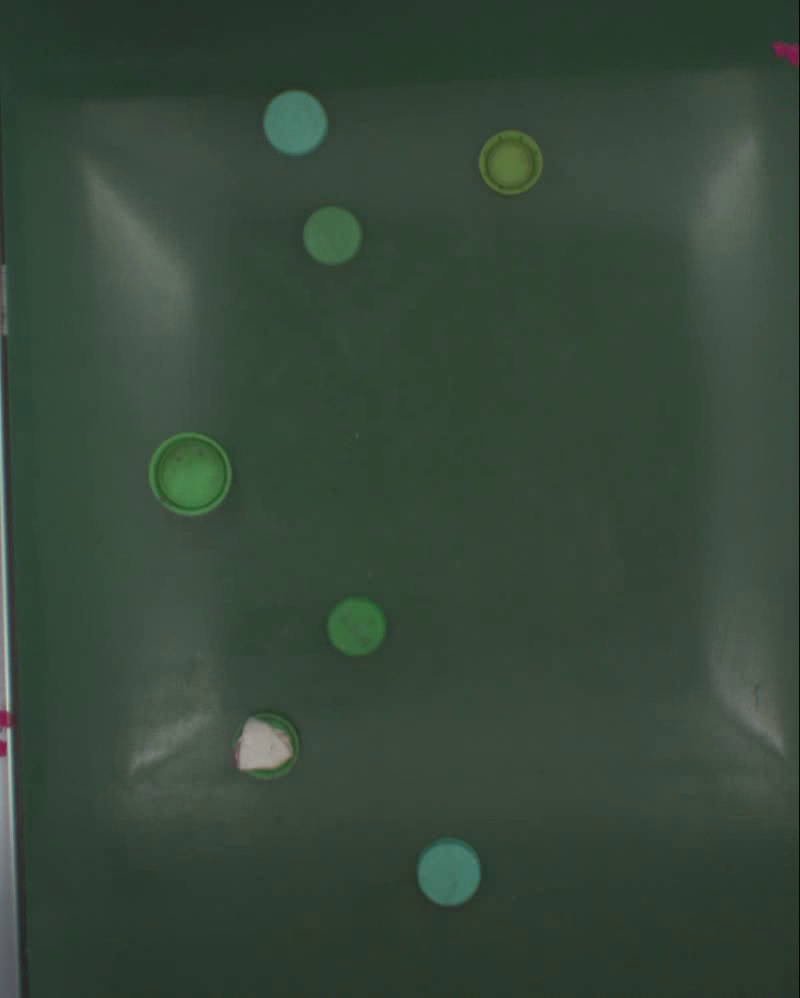

In [72]:
imshow_scale = 1.0
cv2_imshow(cv2.resize(result, None, fx=imshow_scale, fy=imshow_scale))